In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from canari import (
    DataProcess,
    Model,
    SKF,
    plot_data,
    plot_prediction,
    plot_skf_states,
)
from canari.component import LocalTrend, LocalAcceleration, Chronos, WhiteNoise
import json
from prophet import Prophet
import numpy as np


In [2]:
# # Read data
path = "/Users/vuongdai/GitHub/canari/"
data_file = path + "/data/toy_time_series/sine.csv"
df_raw = pd.read_csv(data_file, skiprows=1, delimiter=",", header=None)
data_file_time = path + "./data/toy_time_series/sine_datetime.csv"
time_series = pd.read_csv(data_file_time, skiprows=1, delimiter=",", header=None)
time_series = pd.to_datetime(time_series[0])
df_raw.index = time_series
df_raw.index.name = "date_time"
df_raw.columns = ["values"]

# Add synthetic anomaly to data
trend = np.linspace(0, 0, num=len(df_raw))
time_anomaly = 120
new_trend = np.linspace(0, 1, num=len(df_raw) - time_anomaly)
trend[time_anomaly:] = trend[time_anomaly:] + new_trend
df_raw = df_raw.add(trend, axis=0)

# Data pre-processing
output_col = [0]
data_processor = DataProcess(
    data=df_raw,
    # time_covariates=["hour_of_day"],
    train_split=0.2,
    validation_split=0.8,
    output_col=output_col,
)
train_data, validation_data, test_data, all_data = data_processor.get_splits()

In [3]:
# Components
sigma_v = 5e-2
context_len = 36

local_trend = LocalTrend()
local_acceleration = LocalAcceleration()
chronos = Chronos(
        look_back_len=context_len,
    )
noise = WhiteNoise(std_error=sigma_v)

# Normal model
model = Model(
    local_trend,
    chronos,
    noise,
)

#  Abnormal model
ab_model = Model(
    local_acceleration,
    chronos,
    noise,
)

In [4]:
# # --- Detrend mu_lstm_input using Prophet ---
# prophet_df = pd.DataFrame({
#     "ds": np.array(train_data["time"]).flatten(),
#     "y":  np.array(train_data["y"]).flatten()
# })
# prophet_df["y"] = prophet_df["y"].interpolate()
# prophet_model = Prophet()
# prophet_model.fit(prophet_df)
# trend = prophet_model.predict(prophet_df[["ds"]])["trend"].values
# context = prophet_df["y"] - trend

# model.lstm_output_history.mu = np.array(context)[-context_len:].flatten()
# model.lstm_output_history.time = train_data["time"][-context_len:]

model.lstm_output_history.mu = train_data["y"][-context_len:].flatten()
model.lstm_output_history.time = train_data["time"][-context_len:]

In [5]:
# Switching Kalman filter
skf = SKF(
    norm_model=model,
    abnorm_model=ab_model,
    std_transition_error=1e-2,
    norm_to_abnorm_prob=1e-3,
    abnorm_to_norm_prob=0.01,
)
skf.auto_initialize_baseline_states(validation_data["y"][0:24])

In [6]:
# # Anomaly Detection
filter_marginal_abnorm_prob, states = skf.filter(data=validation_data)

Text(0.5, 1, 'SKF hidden states')

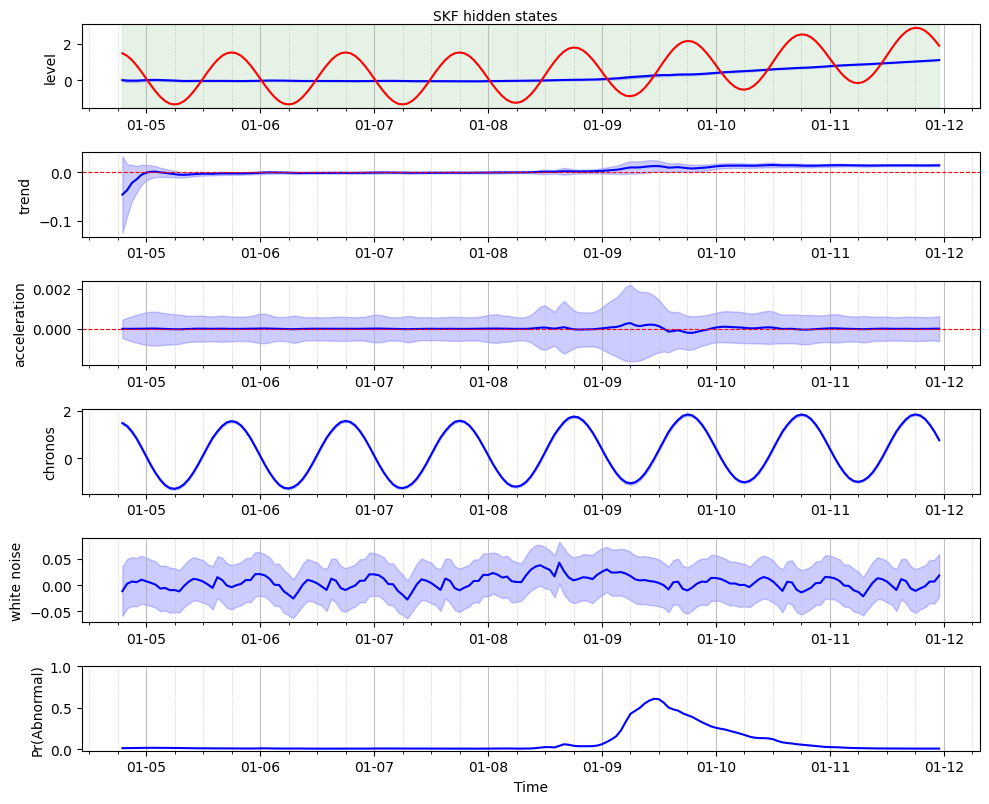

In [7]:
# # Plot
marginal_abnorm_prob_plot = filter_marginal_abnorm_prob

fig, ax = plot_skf_states(
    data_processor=data_processor,
    states=states,
    # states_type="prior",
    model_prob=marginal_abnorm_prob_plot,
    standardization=True,
    color="b",
    plot_observation = True,
    time_start_index = len(train_data["y"]),
)
# ax[0].plot(validation_data["time"], validation_data["y"])
fig.suptitle("SKF hidden states", fontsize=10, y=1)